## Step 1: Install Required Packages

### Purpose
Before starting the analysis, we install additional Python packages that provide tools for:
* Downloading macroeconomic data from the Federal Reserve Economic Data (FRED) database
* Conducting time-series econometric analysis
* Estimating ARIMA and VAR models
* Performing diagnostic and causality tests

### Packages
* **`pandas-datareader`**: Used to access economic data directly from FRED.
* **`statsmodels`**: Provides econometric tools including:
    * Augmented Dickey-Fuller (ADF) tests
    * ARIMA models
    * Vector Autoregressions (VAR)
    * Granger causality tests
    * Residual diagnostics

In [ ]:
# ============================================================
# 1. INSTALL
# ============================================================

!pip install pandas-datareader statsmodels -q

## Step 2: Import Libraries

### Purpose
Load all required libraries for:
* Data management
* Numerical computations
* Visualization
* Time-series econometrics

### Main Libraries

| Library | Purpose |
| :--- | :--- |
| **NumPy** | Numerical calculations |
| **Pandas** | Data handling |
| **Matplotlib** | Visualization |
| **Statsmodels** | Econometric analysis |
| **Pandas DataReader** | Data acquisition |

> **Note:** Warnings are suppressed to keep the notebook output easier to read.

In [ ]:
# ============================================================
# 2. IMPORTS
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pandas_datareader import data as web

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.api import VAR
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox

## Step 3: Download Macroeconomic Data

### Economic Motivation
This study examines the relationship between economic growth and consumer spending in the United States. We collect two quarterly variables from FRED:

* **GDP per Capita**: Measures average economic output per person ($GDP_t$).
* **Personal Consumption Expenditures**: Measures household spending on goods and services ($C_t$).

Consumption is one of the largest components of aggregate demand and is closely linked to economic activity.

### Variables
* **GDP**: $GDP_t$
* **Consumption**: $C_t$

The datasets are merged so that both variables share the same quarterly time index.

In [ ]:
gdp = web.DataReader(
    "A939RX0Q048SBEA",
    "fred",
    start="1950-01-01"
)

# Real Personal Consumption Expenditures, quarterly
cons = web.DataReader(
    "DPCERD3Q086SBEA",
    "fred",
    start="1950-01-01"
)

df = gdp.join(cons, how="inner").dropna()

df.columns = ["gdp", "consumption"]

print(df.head())
print(df.shape)

              gdp  consumption
DATE                          
1950-01-01  15559       12.294
1950-04-01  15977       12.352
1950-07-01  16524       12.610
1950-10-01  16764       12.836
1951-01-01  16922       13.246
(305, 2)


## Step 4: Plot the Raw Series

### Purpose
Before estimating any model, it is important to inspect the data visually. A time-series plot helps identify:
* Long-run trends
* Structural changes
* Business cycles
* Potential non-stationarity

### Expected Observation
Macroeconomic variables measured in levels often display persistent upward trends. If a trend is present, stationarity assumptions may be violated.

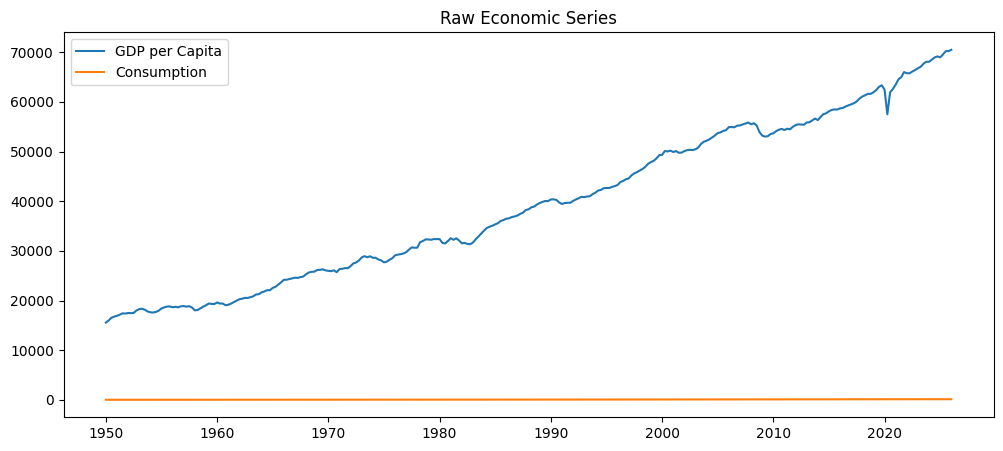

In [ ]:
# ============================================================
# 4. PLOT RAW SERIES
# ============================================================

plt.figure(figsize=(12,5))

plt.plot(df.index, df["gdp"], label="GDP per Capita")
plt.plot(df.index, df["consumption"], label="Consumption")

plt.title("Raw Economic Series")
plt.legend()
plt.show()

## Step 5: Define the Augmented Dickey-Fuller Test Function

### Why Test for Stationarity?
Many econometric models assume that statistical properties remain constant over time. A stationary process has:
* Constant mean
* Constant variance
* Constant covariance structure

### Augmented Dickey-Fuller Test
The ADF test evaluates the presence of a unit root.

* **Null Hypothesis ($H_0$):** $\text{Series contains a unit root}$ (The series is non-stationary).
* **Alternative Hypothesis ($H_1$):** $\text{Series is stationary}$.

### Decision Rule
Reject $H_0$ if:
$$p < 0.05$$

In [ ]:
# ============================================================
# 5. ADF TEST FUNCTION
# ============================================================

def adf_test(series, name):

    result = adfuller(series.dropna())

    print("\n" + "="*50)
    print(name)
    print("="*50)
    print(f"ADF Statistic : {result[0]:.4f}")
    print(f"p-value       : {result[1]:.4f}")

    if result[1] < 0.05:
        print("Stationary")
    else:
        print("Non-stationary")

## Step 6: Test Stationarity of the Level Variables

### Purpose
We first determine whether GDP and Consumption are stationary in levels. Economic variables often follow stochastic trends, which can lead to spurious regression results.

### Why This Matters
If variables are non-stationary:
$$X_t \sim I(1)$$
then standard regression methods may produce misleading inference. Therefore, stationarity must be verified before VAR estimation.

In [ ]:
# ============================================================
# 6. TEST LEVEL SERIES
# ============================================================

adf_test(df["gdp"], "GDP PER CAPITA")
adf_test(df["consumption"], "CONSUMPTION")


GDP PER CAPITA
ADF Statistic : 1.4582
p-value       : 0.9974
Non-stationary

CONSUMPTION
ADF Statistic : 2.3568
p-value       : 0.9990
Non-stationary


## Step 7: Transform Variables into Growth Rates

### Motivation
Since GDP and Consumption are typically non-stationary in levels, we transform them into growth rates using a log-difference transformation.

### Log-Difference Transformation
* **GDP growth:** $$g_t = \ln(GDP_t) - \ln(GDP_{t-1})$$
* **Consumption growth:** $$c_t = \ln(C_t) - \ln(C_{t-1})$$

### Interpretation
For small changes, log differences provide an approximation of percentage growth rates:
$$\Delta \ln(X_t) \approx \%\Delta X_t$$

### Benefits
* Removes trends
* Stabilizes variance
* Improves stationarity
* Simplifies interpretation

In [ ]:
# ============================================================
# 7. CREATE LOG GROWTH RATES
# ============================================================

df["gdp_growth"] = np.log(df["gdp"]).diff()

df["cons_growth"] = np.log(df["consumption"]).diff()

ts = df[
    ["gdp_growth", "cons_growth"]
].dropna()

print(ts.head())

            gdp_growth  cons_growth
DATE                               
1950-04-01    0.026511     0.004707
1950-07-01    0.033664     0.020672
1950-10-01    0.014420     0.017764
1951-01-01    0.009381     0.031442
1951-04-01    0.013209     0.008120


## Step 8: Test Stationarity of Growth Rates

### Purpose
After transforming the variables, we perform the ADF test again. The objective is to verify whether $g_t$ and $c_t$ are stationary.

If stationarity is achieved, the data become suitable for:
* AR models
* VAR models
* Granger causality tests
* Impulse response analysis

In [ ]:
# ============================================================
# 8. TEST STATIONARITY OF GROWTH RATES
# ============================================================

adf_test(ts["gdp_growth"], "GDP GROWTH")
adf_test(ts["cons_growth"], "CONSUMPTION GROWTH")


GDP GROWTH
ADF Statistic : -15.5362
p-value       : 0.0000
Stationary

CONSUMPTION GROWTH
ADF Statistic : -2.5544
p-value       : 0.1028
Non-stationary


## Step 9: Plot Growth Rates

### Purpose
Visualize the transformed series. Unlike the level variables, growth rates should fluctuate around a relatively stable mean.

### What to Look For
* Volatility clustering
* Outliers
* Business-cycle fluctuations
* Mean reversion

> **Note:** A stationary series should not display a persistent trend.

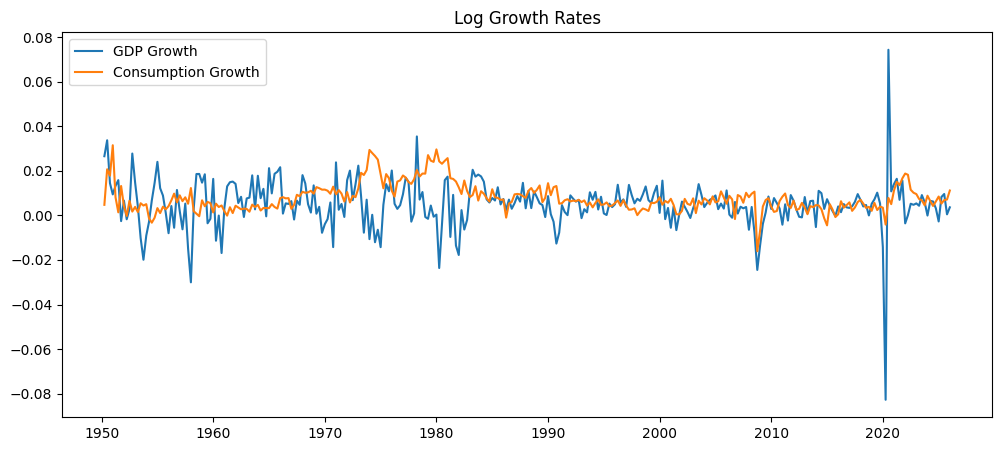

In [ ]:
# ============================================================
# 9. PLOT GROWTH RATES
# ============================================================

plt.figure(figsize=(12,5))

plt.plot(ts.index, ts["gdp_growth"], label="GDP Growth")
plt.plot(ts.index, ts["cons_growth"], label="Consumption Growth")

plt.title("Log Growth Rates")
plt.legend()
plt.show()

## Step 10: Estimate an AR(2) Model for GDP Growth

### Purpose
Before estimating a multivariate VAR model, we analyze GDP growth separately.

### AR(2) Specification
$$g_t = \alpha + \phi_1 g_{t-1} + \phi_2 g_{t-2} + \varepsilon_t$$

Where:
* $\alpha$ = intercept
* $\phi_1, \phi_2$ = autoregressive coefficients
* $\varepsilon_t$ = random shock

### Interpretation
The model tests whether past GDP growth helps explain current GDP growth.

In [ ]:
# ============================================================
# 10. SIMPLE AR MODEL FOR GDP GROWTH
# ============================================================

arma_gdp = ARIMA(
    ts["gdp_growth"],
    order=(2,0,0)
).fit()

print(arma_gdp.summary())

                               SARIMAX Results                                
Dep. Variable:             gdp_growth   No. Observations:                  304
Model:                 ARIMA(2, 0, 0)   Log Likelihood                 946.215
Date:                Mon, 15 Jun 2026   AIC                          -1884.431
Time:                        13:37:34   BIC                          -1869.562
Sample:                    04-01-1950   HQIC                         -1878.483
                         - 01-01-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0050      0.001      5.055      0.000       0.003       0.007
ar.L1          0.1090      0.025      4.348      0.000       0.060       0.158
ar.L2          0.0846      0.080      1.059      0.2

## Step 11: Residual Analysis for the AR Model

### Purpose
A well-specified model should leave only random noise in the residuals. Residual analysis helps detect:
* Remaining patterns
* Autocorrelation
* Misspecification

Ideally, $E(\varepsilon_t) = 0$ and residuals should resemble white noise.

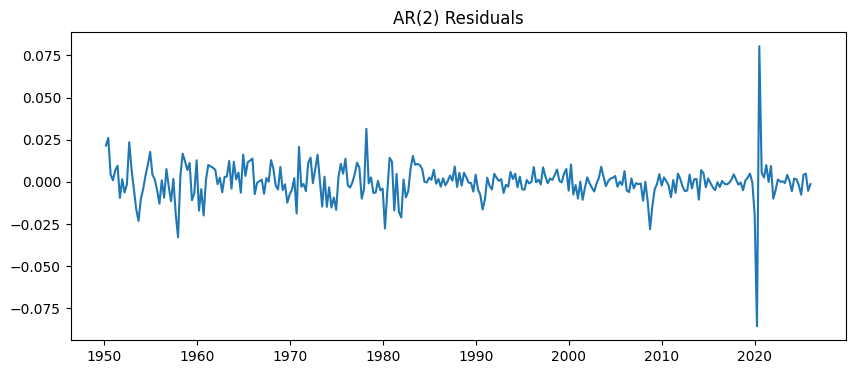

In [ ]:
# ============================================================
# 11. RESIDUAL PLOT
# ============================================================

plt.figure(figsize=(10,4))

plt.plot(arma_gdp.resid)

plt.title("AR(2) Residuals")
plt.show()

## Step 12: Select the VAR Lag Length

### Why Lag Selection Matters
A VAR model includes lagged values of all variables.
* **Too few lags:** Leads to omitted dynamics.
* **Too many lags:** Leads to overfitting and a loss of efficiency.

### Information Criteria
The optimal lag length is chosen by balancing model fit and model complexity using:
* AIC (Akaike Information Criterion)
* BIC (Bayesian Information Criterion)
* HQIC (Hannan-Quinn Information Criterion)
* FPE (Final Prediction Error)

In [ ]:
# ============================================================
# 12. VAR LAG SELECTION
# ============================================================

selector = VAR(ts)

lag_selection = selector.select_order(maxlags=8)

print(lag_selection.summary())

 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -19.24      -19.22   4.403e-09      -19.23
1      -20.33     -20.25*   1.483e-09      -20.30
2      -20.36      -20.23   1.441e-09      -20.31
3     -20.38*      -20.21  1.409e-09*     -20.31*
4      -20.37      -20.14   1.425e-09      -20.28
5      -20.35      -20.08   1.446e-09      -20.24
6      -20.34      -20.01   1.473e-09      -20.21
7      -20.33      -19.96   1.479e-09      -20.18
8      -20.31      -19.89   1.512e-09      -20.14
-------------------------------------------------


## Step 13: Choose the Optimal Lag Order

### Purpose
Select the lag length recommended by the Bayesian Information Criterion (BIC). BIC tends to favor more parsimonious (simpler) models. The selected lag order will be used directly in the VAR estimation.

In [ ]:
# ============================================================
# 13. CHOOSE BIC LAG
# ============================================================

optimal_lag = lag_selection.selected_orders["bic"]

print("Optimal Lag (BIC):", optimal_lag)

Optimal Lag (BIC): 1


## Step 14: Estimate the VAR Model

### Vector Autoregression
A VAR treats all variables as endogenous.

### System of Equations
* **GDP growth equation:**
    $$g_t = a_1 + A_{11}g_{t-1} + A_{12}c_{t-1} + u_{1t}$$
* **Consumption growth equation:**
    $$c_t = a_2 + A_{21}g_{t-1} + A_{22}c_{t-1} + u_{2t}$$

### Purpose
The VAR captures dynamic, bi-directional interactions between GDP growth and Consumption growth.

In [ ]:
# ============================================================
# 14. FIT VAR
# ============================================================

var_model = VAR(ts).fit(optimal_lag)

print(var_model.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 15, Jun, 2026
Time:                     13:38:10
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -20.0257
Nobs:                     303.000    HQIC:                  -20.0698
Log likelihood:           2191.15    FPE:                1.86649e-09
AIC:                     -20.0992    Det(Omega_mle):     1.83007e-09
--------------------------------------------------------------------
Results for equation gdp_growth
                    coefficient       std. error           t-stat            prob
---------------------------------------------------------------------------------
const                  0.005743         0.001016            5.655           0.000
L1.gdp_growth          0.117348         0.056635            2.072           0.038
L1.cons_growth        -0.184502         0.097999   

## Step 15: Check VAR Stability

### Why Stability Matters
Impulse responses and forecasts are only meaningful if the VAR system is stable. A VAR is stable when all eigenvalues lie inside the unit circle.

Mathematically, this requires:
$$|\lambda_i| < 1$$
for all roots. A stable VAR successfully returns to equilibrium after experiencing random shocks.

In [ ]:
# ============================================================
# 15. STABILITY CHECK
# ============================================================

print("VAR Stable:", var_model.is_stable())

VAR Stable: True


## Step 16: Test Residual Autocorrelation

### Ljung-Box Test
The Ljung-Box test examines whether residual autocorrelation remains in the model.

* **Null Hypothesis ($H_0$):** $\text{No residual autocorrelation}$
* **Alternative Hypothesis ($H_1$):** $\text{Residual autocorrelation exists}$

> **Interpretation:** A large p-value suggests the model has adequately captured the dynamic structure of the data.

In [ ]:
# ============================================================
# 16. RESIDUAL AUTOCORRELATION
# ============================================================

for column in var_model.resid.columns:

    print("\n")
    print(column)

    print(
        acorr_ljungbox(
            var_model.resid[column],
            lags=[10],
            return_df=True
        )
    )



gdp_growth
     lb_stat  lb_pvalue
10  4.633008   0.914308


cons_growth
      lb_stat  lb_pvalue
10  28.529996   0.001484


## Step 17: Granger Causality Test (GDP $\rightarrow$ Consumption)

### Research Question
Do past GDP growth rates improve forecasts of Consumption growth?

### Null Hypothesis ($H_0$)
$$GDP \not\Rightarrow Consumption$$
(GDP growth does not Granger-cause Consumption growth).

### Interpretation
Rejecting the null hypothesis implies that lagged GDP growth contains statistically useful predictive information for future Consumption growth.

In [ ]:
# ============================================================
# 17. GRANGER: GDP -> CONSUMPTION
# ============================================================

gdp_causes_cons = var_model.test_causality(
    caused="cons_growth",
    causing=["gdp_growth"],
    kind="f"
)

print(gdp_causes_cons.summary())

Granger causality F-test. H_0: gdp_growth does not Granger-cause cons_growth. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value         df        
--------------------------------------------------------
        0.3678          3.857   0.544 (1, np.int64(600))
--------------------------------------------------------


## Step 18: Granger Causality Test (Consumption $\rightarrow$ GDP)

### Research Question
Do past Consumption growth rates improve forecasts of GDP growth?

### Null Hypothesis ($H_0$)
$$Consumption \not\Rightarrow GDP$$
(Consumption growth does not Granger-cause GDP growth).

In [ ]:
# ============================================================
# 18. GRANGER: CONSUMPTION -> GDP
# ============================================================

cons_causes_gdp = var_model.test_causality(
    caused="gdp_growth",
    causing=["cons_growth"],
    kind="f"
)

print(cons_causes_gdp.summary())

Granger causality F-test. H_0: cons_growth does not Granger-cause gdp_growth. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value         df        
--------------------------------------------------------
         3.545          3.857   0.060 (1, np.int64(600))
--------------------------------------------------------


## Step 19: Summarize the Granger Causality Results

### Purpose
Provide a concise interpretation of the hypothesis tests. The conclusions are based on the significance level:
$$\alpha = 0.05$$

A causal relationship is considered statistically significant when:
$$p < 0.05$$

In [ ]:
# ============================================================
# 19. INTERPRET RESULTS
# ============================================================

print("\nRESULTS")
print("-"*40)

print(
    "GDP -> Consumption:",
    "YES" if gdp_causes_cons.pvalue < 0.05 else "NO"
)

print(
    "Consumption -> GDP:",
    "YES" if cons_causes_gdp.pvalue < 0.05 else "NO"
)


RESULTS
----------------------------------------
GDP -> Consumption: NO
Consumption -> GDP: NO


## Step 20: Impulse Response Functions (IRFs)

### Purpose
Impulse Response Functions trace the dynamic effect of a one-time shock to one variable through the entire VAR system over time.

### Example Questions
* How does Consumption react to a GDP shock?
* How does GDP react to a Consumption shock?
* How long do these dynamic effects persist?

### Concept
A one-unit innovation is introduced at time $t$, and the response of each variable is tracked over future horizons ($h$):
$$IRF(h) = \frac{\partial Y_{t+h}}{\partial \varepsilon_t}$$

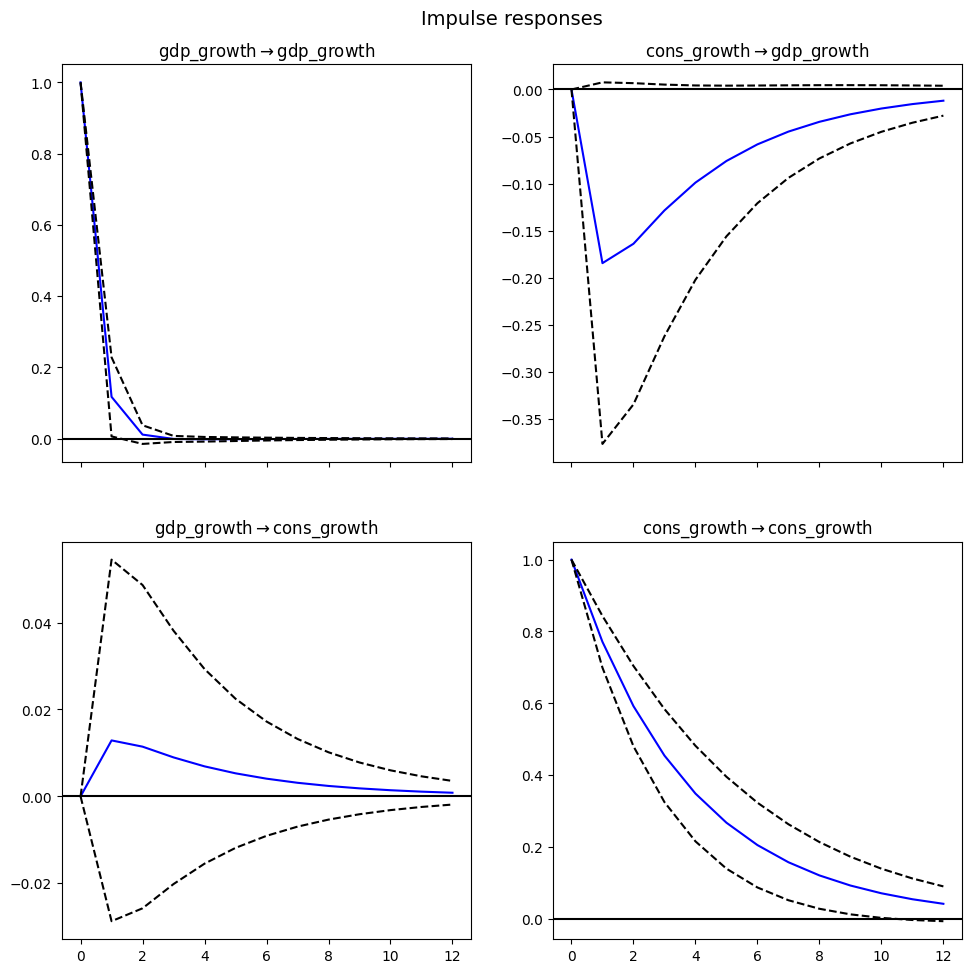

In [ ]:
# ============================================================
# 20. IMPULSE RESPONSE FUNCTIONS
# ============================================================

irf = var_model.irf(12)

irf.plot()

plt.show()

## Step 21: Forecast Error Variance Decomposition (FEVD)

### Purpose
FEVD quantifies the percentage contribution of each type of structural shock to the overall forecast uncertainty of each variable.

### Interpretation
For GDP growth, FEVD answers: *What percentage of future forecast error is explained by unexpected GDP shocks versus unexpected Consumption shocks?*

### General Idea
For a given forecast horizon $h$:
$$\text{Var}(e_{t+h}) = \text{Own Shocks} + \text{Other Variable Shocks}$$
This provides a relative measure of the structural importance of each variable in the system.

In [ ]:
# ============================================================
# 21. FORECAST ERROR VARIANCE DECOMPOSITION
# ============================================================

fevd = var_model.fevd(12)

print(fevd.summary())

FEVD for gdp_growth
      gdp_growth  cons_growth
0       1.000000     0.000000
1       0.995392     0.004608
2       0.991784     0.008216
3       0.989581     0.010419
4       0.988280     0.011720
5       0.987514     0.012486
6       0.987064     0.012936
7       0.986799     0.013201
8       0.986643     0.013357
9       0.986551     0.013449
10      0.986497     0.013503
11      0.986465     0.013535

FEVD for cons_growth
      gdp_growth  cons_growth
0       0.020966     0.979034
1       0.026369     0.973631
2       0.028464     0.971536
3       0.029416     0.970584
4       0.029899     0.970101
5       0.030159     0.969841
6       0.030306     0.969694
7       0.030389     0.969611
8       0.030438     0.969562
9       0.030466     0.969534
10      0.030483     0.969517
11      0.030493     0.969507


None
